# 02 - Data Preparation: Outlier Handling

This notebook focuses only on handling outliers in the target variable `price`.

The feature engineering step will be done later in a separate notebook.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("../dataset/cleaned_base_dataset.csv")

df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-02-05,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-20,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-17,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [41]:
df.shape

(108614, 23)

## Price Outlier Handling

From the data understanding step, the target variable `price` was found to be right-skewed and contains extreme high-price values.

The maximum price is 6735, while the 99th percentile value is 887.0.

The 99th percentile method will be used to remove only the most extreme high-price values. This method is suitable because e-commerce prices are naturally right-skewed, and removing too many high prices may remove valid products.

In [42]:
original_rows = df.shape[0]

price_upper_limit = df["price"].quantile(0.99)

print("Rows before removing outliers:", original_rows)
print("99th percentile price upper limit:", price_upper_limit)

Rows before removing outliers: 108614
99th percentile price upper limit: 887.0


In [43]:
outliers_count = df[df["price"] > price_upper_limit].shape[0]
outliers_percentage = (outliers_count / original_rows) * 100


print("Number of price outliers:", outliers_count)
print("Outliers percentage:", round(outliers_percentage, 2), "%")

Number of price outliers: 1085
Outliers percentage: 1.0 %


In [44]:
df_prepared = df[df["price"] <= price_upper_limit].copy()

df_prepared.shape

(107529, 23)

In [45]:
cleaned_rows = df_prepared.shape[0]
removed_rows = original_rows - cleaned_rows
removed_percentage = (removed_rows / original_rows) * 100

print("Rows before removing outliers:", original_rows)
print("Rows after removing outliers:", cleaned_rows)
print("Removed rows:", removed_rows)
print("Removed percentage:", round(removed_percentage, 2), "%")

Rows before removing outliers: 108614
Rows after removing outliers: 107529
Removed rows: 1085
Removed percentage: 1.0 %


In [46]:
df_prepared["price"].describe()

count    107529.000000
mean        107.020402
std         111.692470
min           0.850000
25%          39.900000
50%          72.990000
75%         129.990000
max         887.000000
Name: price, dtype: float64

## Price Distribution After Removing Outliers

The price distribution is visualized again after removing extreme high-price outliers.

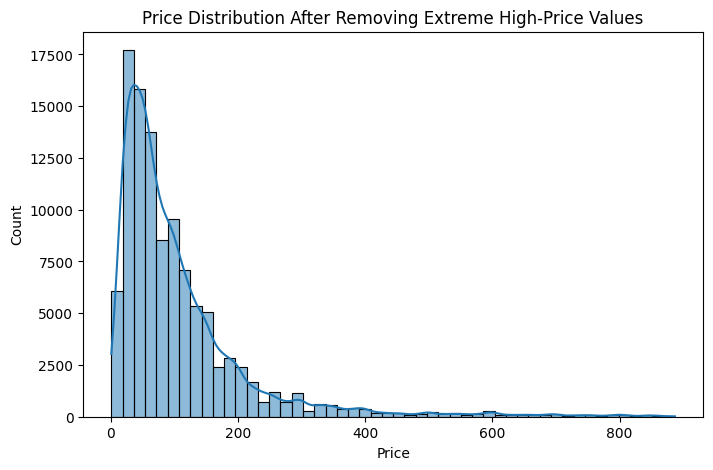

In [47]:
plt.figure(figsize=(8, 5))
sns.histplot(df_prepared["price"], bins=50, kde=True)
plt.title("Price Distribution After Removing Extreme High-Price Values")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

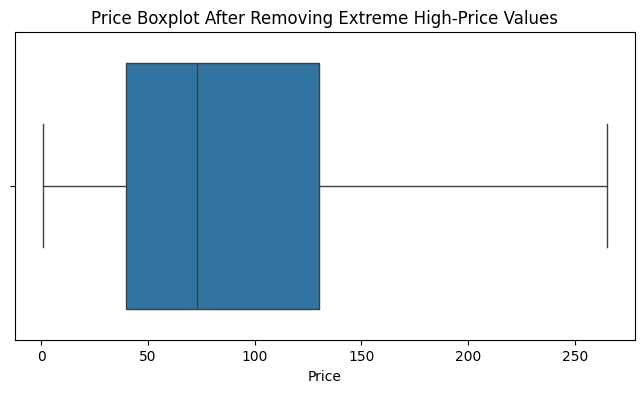

In [48]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_prepared["price"],showfliers=False)
plt.title("Price Boxplot After Removing Extreme High-Price Values")
plt.xlabel("Price")
plt.show()

The boxplot is shown without displaying fliers to make the main price distribution easier to interpret.  
This does not remove any additional rows from the dataset.

In [49]:
print("Maximum price after removing extreme values:", df_prepared["price"].max())
print("Number of rows above upper limit:", (df_prepared["price"] > price_upper_limit).sum())

Maximum price after removing extreme values: 887.0
Number of rows above upper limit: 0


## Save Dataset After Outlier Handling

The dataset after removing price outliers is saved as a new CSV file. This file will be used later in the feature engineering notebook.

In [50]:
df_prepared.to_csv("../dataset/price_outliers_removed_dataset.csv", index=False)

In [51]:
saved_df = pd.read_csv("../dataset/price_outliers_removed_dataset.csv")

saved_df.shape

(107529, 23)

## Outlier Handling Summary

The 99th percentile method was used to remove extreme high-price values from the target variable `price`.

Rows with `price` values greater than 887.0 were removed.

Summary:
- Rows before removing extreme high-price values: 108,614
- Rows after removing extreme high-price values: 107,529
- Removed rows: 1,085
- Removed percentage: 1.0%